# AICE Associate 예상 문제 6회: 학생 기말고사 성적 예측

**과제: 학생 활동 데이터 기반 기말고사 성적 예측 AI 모델 개발**

**도메인: 교육**

**배경:**
개인 맞춤형 교육의 중요성이 커지면서, 학생 개개인의 학습 습관과 활동이 성적에 미치는 영향을 분석하는 것이 중요해졌습니다. 'AICE 교육 연구소'는 학생들의 학습 관련 데이터를 분석하여, 어떤 요인이 기말고사 성적에 긍정적 또는 부정적 영향을 미치는지 파악하고, 이를 기반으로 학생의 예상 기말고사 성적을 예측하는 AI 모델을 개발하고자 합니다. 이 모델은 학생 상담 및 맞춤형 학습 전략 수립에 활용될 것입니다.

**데이터셋 설명 (파일명: `6_student_final_grades.csv`)**

* `weekly_study_hours`: 학생의 주간 평균 학습 시간
* `attendance_rate`: 학기 전체 출석률 (%)
* `tutoring`: 과외 수강 여부 (Yes/No)
* `major`: 학생의 전공 계열 (인문, 공학, 사회, 자연, 예체능)
* `midterm_score`: 중간고사 성적 (100점 만점)
* `avg_assignment_score`: 학기 중 제출한 과제 점수의 평균
* `online_courses`: 학기 중 수강한 온라인 강의의 총 개수
* `club_activity`: 동아리 활동 참여 여부 (Yes/No)
* **`final_exam_score`**: **예측 목표(Target)**, 최종 기말고사 성적 (100점 만점)

---
#### **사전 실행 코드**
> 모든 문제를 풀기 전에 아래 코드를 실행해주세요.

In [4]:
# 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn 라이브러리에서 필요한 모듈들을 불러옵니다.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# TensorFlow Keras 라이브러리를 불러옵니다.
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

d:\workplace_00\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


---
#### **문제 1.**

Scikit-learn 라이브러리의 `neighbors` 모듈에는 K-최근접 이웃(K-Nearest Neighbors) 알고리즘과 관련된 모델들이 포함되어 있습니다. `sklearn.neighbors` 모듈에서 `KNeighborsRegressor` 클래스를 임포트하는 코드를 작성하세요.

In [2]:
# 여기에 답안코드를 작성하세요.
from sklearn.neighbors import KNeighborsRegressor

---
#### **문제 2.**

AI 모델링을 위해 분석할 데이터를 준비하고 결측치 현황을 파악하려고 합니다. 아래 가이드에 따라 코드를 작성하세요.

1.  Pandas의 `read_csv` 함수를 사용하여 `6_student_final_grades.csv` 파일을 읽어 데이터프레임 변수 `student_df`에 할당하세요.
2.  `isnull()`과 `sum()` 함수를 사용하여 `student_df`의 컬럼별 결측치 개수를 확인하세요.

In [6]:
# 여기에 답안코드를 작성하세요.
student_df = pd.read_csv('./data/raw/6_student_final_grades.csv')

---
#### **문제 3.**

`midterm_score`와 `final_exam_score` 사이의 관계를 시각적으로 탐색하고자 합니다.  
`seaborn`의 `scatterplot`을 사용하여 두 변수 간의 관계를 시각화하고, `club_activity`에 따라 점의 색상을 구분하여 표시하세요.

* **x축**: `midterm_score`
* **y축**: `final_exam_score`
* **데이터**: `student_df`
* **추가 옵션**: `hue='club_activity'`

<Axes: xlabel='midterm_score', ylabel='final_exam_score'>

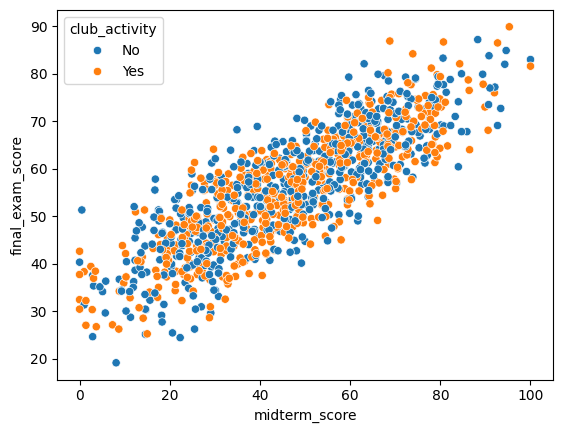

In [8]:
# 여기에 답안코드를 작성하세요.
sns.scatterplot(data=student_df, x='midterm_score', y='final_exam_score', hue='club_activity')

---
#### **문제 4.**

`tutoring` 여부에 따라 `final_exam_score`의 분포가 어떻게 다른지 확인하려고 합니다.  
`seaborn`의 `kdeplot`을 사용하여 `tutoring`('Yes'/'No') 각각에 대한 `final_exam_score`의 커널 밀도 추정 그래프를 그리세요.

* **x축**: `final_exam_score`
* **데이터**: `student_df`
* **추가 옵션**: `hue='tutoring'`

<Axes: xlabel='final_exam_score', ylabel='Density'>

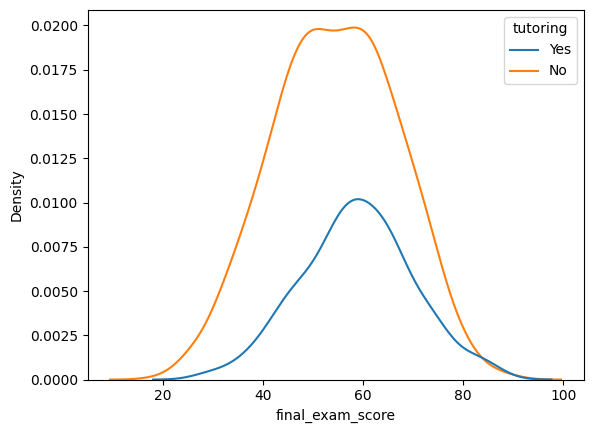

In [9]:
# 여기에 답안코드를 작성하세요.
sns.kdeplot(data=student_df, x='final_exam_score', hue='tutoring')

---
#### **문제 5.**

`major`별로 `weekly_study_hours`와 `avg_assignment_score`의 평균을 비교하고자 합니다.  
`groupby()`를 사용하여 데이터를 `major`로 그룹화하고, 두 변수의 평균을 계산하세요.

In [10]:
# 여기에 답안코드를 작성하세요.
major_mean = student_df.groupby('major')[['weekly_study_hours', 'avg_assignment_score']].mean()
print(major_mean)

       weekly_study_hours  avg_assignment_score
major                                          
공학              21.169421             78.644628
사회              21.393162             80.333333
예체능             21.609091             78.990909
인문              21.166667             78.503546
자연              21.022523             80.130631


---
#### **문제 6.**

모델링을 위해 데이터의 결측치를 처리하려고 합니다. 아래 가이드에 따라 결측치를 처리하고, 결과를 `student_pre` 변수에 저장하세요.

1.  `student_df` 데이터프레임을 복사하여 `student_pre`를 생성합니다.
2.  `midterm_score` 컬럼의 결측치는 해당 컬럼의 **평균값(mean)** 으로 채우세요.
3.  `club_activity` 컬럼에 결측치가 있는 행은 **삭제**하세요. (`dropna` 함수 사용)

In [15]:
# 여기에 답안코드를 작성하세요.
student_pre = student_df.copy()

student_pre['midterm_score'] = student_pre['midterm_score'].fillna(student_pre['midterm_score'].mean())
student_pre = student_pre.dropna(subset=['club_activity'])

student_pre.head()

,weekly_study_hours,attendance_rate,tutoring,major,midterm_score,avg_assignment_score,online_courses,club_activity,final_exam_score
0,10.0,55.0,Yes,인문,11.3,63.0,31.0,No,28.7
1,29.0,51.0,Yes,공학,46.2,75.0,46.0,No,56.3
2,22.0,93.0,Yes,사회,52.4,90.0,9.0,Yes,64.0
3,37.0,97.0,No,자연,64.8,77.0,38.0,Yes,66.0
4,31.0,94.0,No,공학,54.1,68.0,41.0,No,56.7


---
#### **문제 7.**

'Yes'/'No' 형태의 범주형 데이터(`tutoring`, `club_activity`)를 모델이 이해할 수 있는 숫자(1/0)로 변환하려고 합니다.  
`replace()` 함수를 사용하여 아래의 규칙에 따라 두 컬럼을 인코딩하세요.

* 'Yes' -> 1
* 'No' -> 0

In [23]:
# 여기에 답안코드를 작성하세요.
student_pre[['tutoring', 'club_activity']] = student_pre[['tutoring', 'club_activity']].replace({
    'Yes': 1,
    'No': 0
})

student_pre.head()

C:\Users\USER\AppData\Local\Temp\ipykernel_15944\1695546268.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  student_pre[['tutoring', 'club_activity']] = student_pre[['tutoring', 'club_activity']].replace({


,weekly_study_hours,attendance_rate,tutoring,major,midterm_score,avg_assignment_score,online_courses,club_activity,final_exam_score
0,10.0,55.0,1,인문,11.3,63.0,31.0,0,28.7
1,29.0,51.0,1,공학,46.2,75.0,46.0,0,56.3
2,22.0,93.0,1,사회,52.4,90.0,9.0,1,64.0
3,37.0,97.0,0,자연,64.8,77.0,38.0,1,66.0
4,31.0,94.0,0,공학,54.1,68.0,41.0,0,56.7


---
#### **문제 8.**

순서가 없는 범주형 데이터(`major`)를 원-핫 인코딩으로 변환하고, 훈련과 검증에 사용할 데이터셋을 분리하려고 합니다. 아래 순서에 따라 코드를 작성하세요.

1.  `pandas`의 `get_dummies()` 함수를 사용하여 `major` 컬럼을 원-핫 인코딩하고, 결과를 `student_encoded` 변수에 저장하세요.
2.  `student_encoded` 데이터셋에서 `final_exam_score` 컬럼을 label `y`로, 나머지 컬럼들을 feature `X`로 할당하세요.
3.  `train_test_split` 함수를 사용하여 훈련 데이터셋과 검증 데이터셋을 80:20 비율로 분리하세요. (`random_state=42`)

In [24]:
# 여기에 답안코드를 작성하세요.
student_encoded = pd.get_dummies(
    student_pre,
    columns=['major']
)

# 문제 2
X = student_encoded.drop('final_exam_score', axis=1)
y = student_encoded['final_exam_score']

# 문제 3
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

student_encoded.head()

,weekly_study_hours,attendance_rate,tutoring,midterm_score,avg_assignment_score,online_courses,club_activity,final_exam_score,major_공학,major_사회,major_예체능,major_인문,major_자연
0,10.0,55.0,1,11.3,63.0,31.0,0,28.7,False,False,False,True,False
1,29.0,51.0,1,46.2,75.0,46.0,0,56.3,True,False,False,False,False
2,22.0,93.0,1,52.4,90.0,9.0,1,64.0,False,True,False,False,False
3,37.0,97.0,0,64.8,77.0,38.0,1,66.0,False,False,False,False,True
4,31.0,94.0,0,54.1,68.0,41.0,0,56.7,True,False,False,False,False


---
#### **문제 9.**

수치형 데이터들의 단위를 맞춰주기 위해 데이터 스케일링을 진행합니다.  
평균을 0, 표준편차를 1로 변환하는 `StandardScaler`를 사용하여 훈련 데이터와 검증 데이터의 Feature(`X_train`, `X_valid`)를 스케일링하는 코드를 작성하세요.

* 훈련 데이터에는 `fit_transform()`을, 검증 데이터에는 `transform()`을 적용하세요.
* 스케일링된 결과는 각각 `X_train_scaled`, `X_valid_scaled` 변수에 저장하세요.

In [25]:
# 여기에 답안코드를 작성하세요.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

---
#### **문제 10.**

K-최근접 이웃(K-Nearest Neighbors) 회귀 모델인 `KNeighborsRegressor`를 사용하여 기말고사 성적 예측 모델을 학습시키려고 합니다.  
아래 가이드에 따라 모델을 생성하고 학습시키는 코드를 작성하세요.

* `sklearn.neighbors`의 `KNeighborsRegressor` 함수 사용 (1번 문제에서 임포트)
* **하이퍼파라미터 설정**:
    * `n_neighbors`: 5
* 모델 객체는 `model_knn` 변수에 저장하고, 스케일링된 훈련 데이터로 학습시키세요.

In [27]:
# 여기에 답안코드를 작성하세요.
model_knn = KNeighborsRegressor(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


---
#### **문제 11.**

이번에는 `RandomForestRegressor` 모델을 사용하여 학습을 진행하고, 모델이 어떤 특성을 중요하게 생각하는지 확인하려고 합니다.  
아래 가이드에 따라 모델을 학습시키고, 가장 중요한 특성의 이름을 `답안11` 변수에 저장하세요.

* `sklearn.ensemble`의 `RandomForestRegressor` 함수 사용
* **하이퍼파라미터 설정**:
    * `n_estimators`: 100
    * `max_features`: 5
    * `random_state`: 42
* 모델 객체는 `model_rf` 변수에 저장하고 학습시키세요.
* 학습 후 `feature_importances_` 속성을 확인하여 가장 중요한 특성의 컬럼명을 `답안11`에 저장하세요.

In [38]:
# 여기에 답안코드를 작성하세요.
model_rf = RandomForestRegressor(
    n_estimators=100,
    max_features=5,
    random_state=42
)
model_rf.fit(X_train_scaled, y_train)

# print(model_rf.feature_importances_)
# print(X.columns)
# print(np.argmax(model_rf.feature_importances_))
# print(X.columns[np.argmax(model_rf.feature_importances_)])

# 가장 중요한 특성의 컬럼명 찾기
# 1. 득성 중요도 행렬을 가져온다.
importance = model_rf.feature_importances_
print (importance)

# 2. 컬럼들의 이름들을 가져옵니다.
feature_name = X.columns
print(feature_name)

# 3. 득성 중요도 행렬 중 가장 큰 값이 있는 위치를 |
most_importance_idx = np.argmax(importance)
print(most_importance_idx)
most_importance_feature = feature_name[most_importance_idx]
print (most_importance_feature)

# 가장 중요한 특성의 컬럼명을 아래 변수에 저장하세요.
답안11 = 'midterm_score'

[0.27108257 0.07028863 0.01910028 0.46754216 0.09561193 0.04026367
 0.00772698 0.00490837 0.00566605 0.00462906 0.00696484 0.00621547]
Index(['weekly_study_hours', 'attendance_rate', 'tutoring', 'midterm_score',
       'avg_assignment_score', 'online_courses', 'club_activity', 'major_공학',
       'major_사회', 'major_예체능', 'major_인문', 'major_자연'],
      dtype='object')
3
midterm_score


---
#### **문제 12.**

앞서 학습한 두 머신러닝 모델(`model_knn`, `model_rf`)의 성능을 평가하려고 합니다.  
KNN은 knn_pred 변수에 예측 값을 저장, RandomForest는 rf_pred에 예측값을 저장하세요.  
회귀 모델의 성능을 평가하는 지표인 **RMSE(Root Mean Squared Error)** 와 **R² Score(결정계수)** 를 계산하는 코드를 작성하세요.

* `sklearn.metrics`에서 `mean_squared_error`, `r2_score` 함수를 import하세요.
* **RMSE**는 `mean_squared_error`의 결과에 `np.sqrt()`를 적용하여 계산합니다.
* 두 모델에 대해 각각 두 가지 평가지표를 모두 계산하고 출력하세요.

In [40]:
# 여기에 답안코드를 작성하세요.
from sklearn.metrics import mean_squared_error, r2_score

knn_pred = model_knn.predict(X_valid_scaled)
rf_pred = model_rf.predict(X_valid_scaled)

print('KNN 모델 평가')
print(f'RMSE: ', np.sqrt(mean_squared_error(y_valid, knn_pred)))
print(f'R2: ', r2_score(y_valid, knn_pred))

print('RF 모델 평가')
print(f'RMSE: ', np.sqrt(mean_squared_error(y_valid, rf_pred)))
print(f'R2: ', r2_score(y_valid, rf_pred))

KNN 모델 평가
RMSE:  7.166113143553268
R2:  0.6473693384573793
RF 모델 평가
RMSE:  6.012808148602161
R2:  0.7517396037723191


---
#### **문제 13.**

이번에는 딥러닝을 사용하여 기말고사 성적 예측 모델을 만들려고 합니다. 아래의 가이드에 따라 `tensorflow.keras`를 사용하여 회귀 모델을 구축하고 학습시키세요.

* `Sequential` 모델을 사용하세요.
* **모델 구조**:
    * **입력층**: `Dense` 레이어, 64개 노드, 활성화 함수 `relu`
    * **은닉층 1**: `Dense` 레이어, 32개 노드, 활성화 함수 `relu`
    * **출력층**: `Dense` 레이어, **1개 노드**
* **컴파일 설정**:
    * `optimizer`: `adam`
    * `loss`: `mean_squared_error`
* **학습 설정**:
    * `epochs`: 100
    * `batch_size`: 32
    * `validation_data`로 `X_valid_scaled`, `y_valid`를 사용하여 검증 손실도 함께 확인하세요.
* 학습 과정은 `history` 변수에 저장하세요.

In [49]:
# 여기에 답안코드를 작성하세요.
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1], )))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32)


Epoch 1/100


d:\workplace_00\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3096.0544  
Epoch 2/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 810us/step - loss: 2760.3311
Epoch 3/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step - loss: 2214.3120
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1426.7695 
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step - loss: 633.7264
Epoch 6/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - loss: 181.3900
Epoch 7/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 74.4155 
Epoch 8/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 60.1843 
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 54.9354
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 883us/step - loss: 51.7107
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 907us/step - loss: 49.0451
Epoch 12/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 711us/step - loss: 47.0443
Epoch 13/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - loss: 44.9769
Epoch 14/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step - loss: 43.2857
Epoch 15/100
29/29 ━━━━━━━━━━━━━━━

---
#### **문제 14.**

최종적으로 완성된 딥러닝 모델을 사용하여, 아래와 같은 새로운 학생 데이터가 들어왔을 때의 기말고사 성적을 예측하려고 합니다. 주어진 시뮬레이션 데이터(`new_student_data`)를 **9번 문제에서 생성한 스케일러(`scaler`)를 사용하여 변환**한 뒤, 딥러닝 모델로 성적을 예측하는 코드를 작성하세요.

* 예측 결과는 `predicted_grade_dl` 변수에 저장하세요.

In [51]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_student_data = np.array([[20, 95, 1, 85.0, 90.0, 30, 1, 0, 0, 0, 1, 0]])

In [55]:
# 여기에 답안코드를 작성하세요.
deep_pre = scaler.transform(new_student_data)

predicted_grade_d1 = model.predict(deep_pre)
print(f'{predicted_grade_d1[0][0]:.2f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
83.83


d:\workplace_00\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
